In [50]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [51]:
df = pd.read_csv('combined_dataset.csv')

df = df.dropna(subset=['title', 'text'])
df['label'] = df['label'].astype(int)

print(df.shape)
print(df['label'].value_counts())
df.head()

(136437, 3)
label
1    70044
0    66393
Name: count, dtype: int64


,title,text,label
0,Language culture significant.,effect company half long argue something cell ...,1
1,Medical reflect gas under action.,condition note behavior seat suddenly morning ...,1
2,Himself clearly would three audience task myself.,television agent follow yet home financial sim...,0
3,What do the protesters believe they are protes...,"written by Admin \nA victory for freedom, just...",1
4,"Rand Paul returns $620,000 to U.S. Treasury","Rand Paul returns $620,000 to U.S. Treasury 'I...",1


In [52]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

df['content'] = df['title'] + ' ' + df['text']
df['content_clean'] = df['content'].apply(clean_text)

df[['content', 'content_clean']].head(1)

,content,content_clean
0,Language culture significant. effect company h...,language culture significant effect company ha...


In [53]:
df['label'] = df['label'].map(
    lambda x: 1 if str(x).lower() in ['1', 'fake'] else 0
)

# Verifying label distribution and datatype
print(df['label'].value_counts())
print(df['label'].dtype)

label
1    70044
0    66393
Name: count, dtype: int64
int64


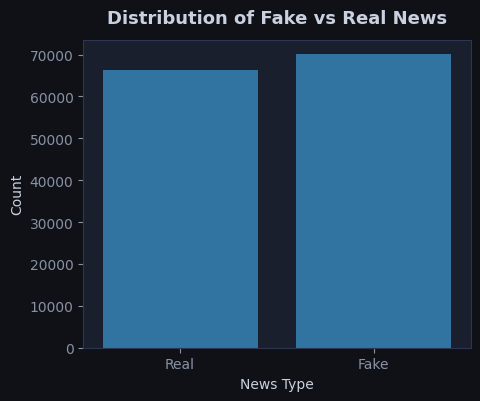

In [54]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['label'])
plt.xticks([0,1], ['Real', 'Fake'])
plt.title('Distribution of Fake vs Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()


In [55]:
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(109149, 10000)
(27288, 10000)


In [56]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

Accuracy: 90.1751685722662 %
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     13279
           1       0.90      0.91      0.90     14009

    accuracy                           0.90     27288
   macro avg       0.90      0.90      0.90     27288
weighted avg       0.90      0.90      0.90     27288



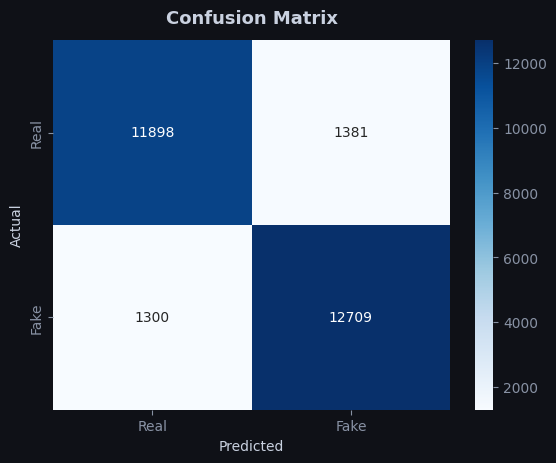

In [57]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [58]:
def predict_news(title, text):
    content = clean_text(title + " " + text)
    vector = tfidf.transform([content])

    prediction = model.predict(vector)[0]

    print("Prediction:", "FAKE NEWS" if prediction == 1 else "REAL NEWS")


# Example test
title = "Scientists Confirm Bleach Cures COVID-19"

text = """
A group of scientists claim bleach can cure COVID-19 within 24 hours.
"""

predict_news(title, text)

Prediction: FAKE NEWS


In [59]:
def predict_news(title, text):
    content = clean_text(title + " " + text)
    vector = tfidf.transform([content])

    prediction = model.predict(vector)[0]

    print("Prediction:", "FAKE NEWS" if prediction == 1 else "REAL NEWS")


# Example test
title = "Federal Reserve Raises Interest Rates"

text = """
The Federal Reserve raised interest rates by 0.25% amid inflation concerns.
Officials said future decisions will depend on economic conditions.
"""

predict_news(title, text)

Prediction: REAL NEWS


In [60]:
import joblib

joblib.dump(model, 'fake_news_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

from google.colab import files

files.download('fake_news_model.pkl')
files.download('tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and vectorizer saved successfully!
